# Code for the Paper ‘Spatially Dependent Risk Pools’

The purpose of this notebook is to allow users to become familiar with the code for the paper <i>Spatially Dependent Risks Pools</i>.

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/SpatialRiskPool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

<br><br><br>
Only selected portions of the code are demonstrated in this notebook. You can see a more detailed explanation of the code at

https://users.ssc.wisc.edu/~ewfrees/SpatialData/FloodCode2026.html





#  Getting Started

Start by going to "Runtime", select "Change Runtime Type", ensure that "R" is selected, and click "Save".

As before, you can make changes to a Colab notebook, and they will persist for as long as you keep your browser tab open. But once you close it, the changes will be lost. To avoid this, make sure you save a copy of the notebook to your Google Drive by selecting File → “Save a copy in Drive”.

## Load Libraries

As is the custom with Jupyter notebooks, we start by loading some libraries that are going to be helpful. In the following code, we also indicate where the libraries are needed with comments.

In [ ]:
library(dplyr)
library(ggplot2)
install.packages("alabama")
library(alabama)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: numDeriv



## Importing Saved Calculations

To save time, I have saved many intermediate calculations in the folder "https://users.ssc.wisc.edu/~ewfrees/SpatialData/". I will refer to them occasionally and you can view all of them by clicking on this link.

Here is some sample code. It is not needed now and so is commented out.

In [ ]:
# This is the base method that we wish to repeat. Hence, the function.
#download.file("https://users.ssc.wisc.edu/~ewfrees/SpatialData/RDataFiles/
#                        testDataSamp_08June2026.RData",
#              destfile = "testDataSamp_08June2026.RData")
#load(file = "testDataSamp_08June2026.RData")

GetData.fct <- function(file){
  remote_url <- "https://users.ssc.wisc.edu/~ewfrees/SpatialData/RDataFiles/"
  full_data_url <- paste0(remote_url, file)
  download.file(full_data_url, destfile = file)
  load(file, envir = .GlobalEnv)
  }

#GetData.fct("testDataSampInd_08June2026.RData")
#ls.str() # List objects with details


#  A Toy Example

To emphasize the importance of spatial dependencies, let us start with a simple example. This is in Section 5.1 of the paper.

Let us illustrate these ideas in a very simple situation. Assume that a risk owner has $n=10$ properties with random losses $X_1, \ldots, X_{10}$. For simplicity, we assume that the properties have the same loss distribution.

#### Set Spatial Locations {-}

However, we will allow them to be dependent spatially. To this end, we assume that the property locations, denoted by $s$, are known. Again, for simplicity, we assume they fall along a single dimension and are given by: 1, 2, 3, 6, 7, 8, 9, 16, 17, and 18.


In [ ]:
# Your data
cluster1   <- c(1, 2, 3)
cluster2   <- c(cluster1, 4) + 5
cluster3   <- cluster1 + 15
loc_       <- c(cluster1, cluster2, cluster3)
clusterIndex <- c(rep(1,3), rep(2, 4), rep(3, 3))


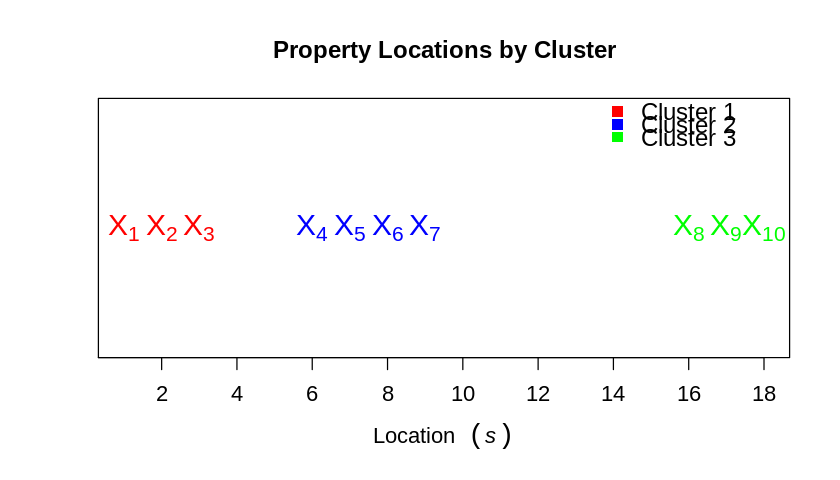

In [ ]:
#  Visualize these data
options(repr.plot.width = 7, repr.plot.height = 4)
colors <- c("red", "blue", "green")[clusterIndex]
# Subscript labels
labels <- lapply(seq_along(loc_), function(i) bquote(X[.(i)]))
# Plot with tighter ylim
plot(loc_, rep(1, length(loc_)),
     type = "n",
     yaxt = "n", xaxt = "n",
     ylim = c(0.98, 1.02),     # even tighter vertical space
     xlab = expression(Location~(italic(s))), cex.lab = 1.1,
     ylab = "",
     main = "Property Locations by Cluster")
axis(side = 1, at = seq(0, 18, by = 2), labels = seq(0, 18, by = 2),
     cex.axis = 1.1)
# Add subscripted labels
for (i in seq_along(loc_)) {
  text(loc_[i], 1, labels[[i]], col = colors[i], cex = 1.5)
}
# Add legend
legend("topright", #inset = c(-0.13, 0),
       legend = c("Cluster 1", "Cluster 2", "Cluster 3"),
       col = c("red", "blue", "green"),
       pch = 15, bty = "n", xpd = TRUE,
       cex = 1.2)

#### Correlation Structure

For the correlation structure, let us use the dependence function
$$
K(s_i, s_j) = \exp\left(-
\frac{|s_i - s_j|}{\phi_{dep}} .
\right),
$$
with a value of $\phi_{dep}=5$ providing sensible values.

In [ ]:
dep_param  <- 5
clusterIndex <- c(rep(1,3), rep(2, 4), rep(3, 3))
n          <- length(loc_)
dist_loc   <- matrix(0,n,n)
for (irow in 1:n) {
  for (jrow in 1:n) {
     dist_loc[irow,jrow] = abs(loc_[irow] - loc_[jrow])
  }}
# Spatial correlation
spat_corr  <- exp(- dist_loc / dep_param)
ExpX       <- as.vector(rep(1, n)) -> ones
stdevVec   <- rep(1, n)
BigSigma   <- diag(stdevVec) %*% spat_corr %*% diag(stdevVec)

##  Optimizing Risk Retention Using First Principles

Mostly follow [Section 3.4.1](https://users.ssc.wisc.edu//~ewfrees/InsurableRisks/C3Balance.html#markowitz-portfolio-optimization) of the book for notation, but to simplify things, let us use $\boldsymbol{\mu} = (\mu_1 , \ldots, \mu_p)'$ to denote the vector of mean returns of $p$ asset risks.


Our problem is:

*   **Minimize**: $\mathbf{c}^{\prime} ~\boldsymbol \Sigma~\mathbf{c}$ (uncertainty measured by the variance)
*   **Subject to**: $(\mathbf{1}-\mathbf{c})^{\prime} ~\boldsymbol {\mu} \le RTC_{max}$ (budget for risk transfer)
*   **Subject to**: $c_j \ge 0$ (non-negative weights)
*   **Subject to**: $c_j \le 1$ for all $j$ (weights less than one)

To summarize, the problem we wish to solve is

$$\boxed{
\begin{array}{lc}
{\small \text{minimize}}_{\mathbf{c}}  &  \mathbf{c}^{\prime} ~\boldsymbol \Sigma~\mathbf{c}  \\
{\small \text{subject to}} & (\mathbf{1}-\mathbf{c})^{\prime} ~\boldsymbol {\mu} \le RTC_{max} \\
& 0 \le c_j \le 1 \\
\end{array}
}
$$

### Optimization with `alabama::auglag`

We will use the `auglag` function for general constrained optimization. It requires:

*   An objective function (`fn`) to minimize.
    *   Optionally, a gradient function for `fn` (`gr`).
*   An inequality constraint function (`hin`) where `hin(x) >= 0`.
    *   Optionally, a gradient function for `hin` (`jac_hin`).
*   An equality constraint function (`heq`) where `heq(x) == 0`.
    *   Optionally, a gradient function for `heq` (`jac_heq`).



In [ ]:
#install.packages("alabama")
#library(alabama)
optParams <- function(RTCmax_param = 0.2, dep_param  = 5, clusterSep = 5 ){
    #  Location Specification
  cluster1 = c(1, 2, 3)
  cluster2 = c(cluster1, 4) + clusterSep
  cluster3  = cluster1 + 3*clusterSep
  loc_ = c(cluster1, cluster2, cluster3)
  n = length(loc_)
  # Spatial correlation
  spat_corr  <- exp(- dist_loc / dep_param)
  stdevVec   <- rep(1, n)
  BigSigma   <- diag(stdevVec) %*% spat_corr %*% diag(stdevVec)

  RTCmax <- RTCmax_param * sum(ExpX)
  f0.ala <- function(par){t(par) %*% BigSigma %*% par}
  f1.ala <- function(par){-(t(ExpX) %*% (ones-par)- RTCmax)}
  hin <- function(par) {h <- NA
    h[1] <- f1.ala(par)
    for (j in 1:n){h[j+1] <- 1 - par[j] } # upper bound of one
    for (j in 1:n){h[j+11] <- par[j] } # lower bound of zero
    return(h)
    }
   var.opt <- alabama::auglag(par=ones, # initial value
            fn=f0.ala,           # objective function
            hin=hin,             # inequality constraints
            control.outer=list(method="nlminb",trace=FALSE))
   cstar <- var.opt$par
   return(c(n, loc_, cstar) )
}
cstarloc  <- optParams(RTCmax_param = 0.2)
cstarloc


[1] 10.0000000  1.0000000  2.0000000  3.0000000  6.0000000  7.0000000
 [7]  8.0000000  9.0000000 16.0000000 17.0000000 18.0000000  1.0000000
[13]  0.9583898  0.6318136  0.6318017  0.3220854  0.4559095  1.0000000
[19]  1.0000000  1.0000000  1.0000000

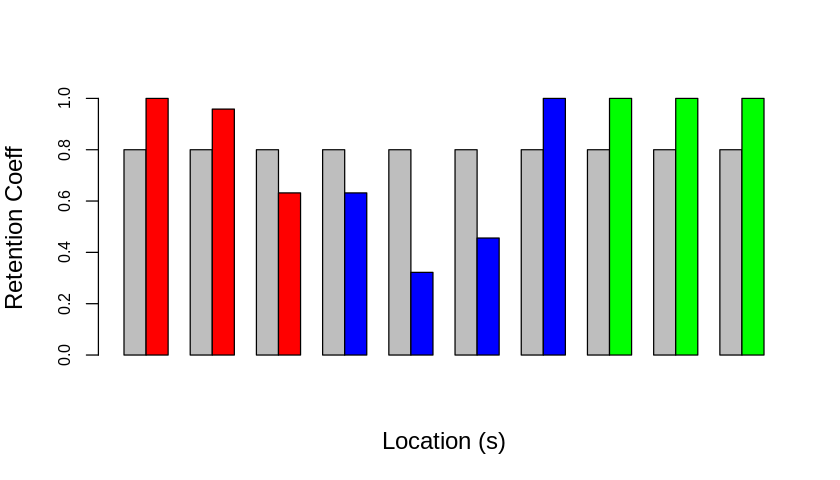

In [ ]:
n         <- cstarloc[1]
loc_      <- cstarloc[2:(n+1)]
cstar_index <- (n+2):(2*n+1)
cstar_dep <- cstarloc[cstar_index]
cstar_ind <- optParams(RTCmax_param = 0.2, dep_param = 1e8)[cstar_index]
c_all <- cbind("Independent" = cstar_ind,
               "Dependent"   = cstar_dep)
cluster_colors <- c(rep("red", 6),     # Cluster 1 (3 bars)
                    rep("blue", 8),    # Cluster 2 (4 bars)
                    rep("green", 6))   # Cluster 3 (3 bars)
cluster_colors[c(1,3,5,7,9,11,13,15,17,19)] <- "grey"
barplot(t(c_all), legend = NULL,
        cex=0.8, args.legend = list(x = "topright", ncol = 1, cex=0.6),
        col = cluster_colors,
        cex.names=0.6, beside = TRUE, cex.lab=1.2, main = "",
        xlab = "Location (s)", ylab = "Retention Coeff")

In the above code, the dependence parameter is `dep_param` and a term that measures how far apart is `clusterSep`. Try changing the dependence parameter and the cluster separation and see the effects on the risk retention coefficients `cstarloc`.

# Demonstration 1. Predictive Distributons

In the more detailed code source, https://users.ssc.wisc.edu/~ewfrees/SpatialData/FloodCode2026.html, you will find a description of how to estimate a dependence model based on flood risk data.

In addition, you will find see how to generate predictive distributions for a test sample based on these estimated distributions. Several alternative predictive distributions are considered.

The first step is to show that the <i>spatial dependence matters</i> (otherwise, why bother?).

To this end, the following table shows that the distribution of the *independence* claims is tighter than the others.

See also the following Figure. Here, the grayscale is the base approach (most likely based on the estimation procedures) which is our best estimate of spatial dependencies.




In [ ]:
#download.file("https://users.ssc.wisc.edu/~ewfrees/SpatialData/RDataFiles/
#                                  TotalClaimsByDependency.RData",
#              destfile = "TotalClaimsByDependency.RData")
GetData.fct(file = "TotalClaimsByDependency.RData")

TableOut <- rbind(SumDatBase1[[1]],  SumDatBase2[[1]], SumDatBase3[[1]],
                  SumDatBase4[[1]],  SumDatBase5[[1]],  SumDatBase6[[1]]   )
rownames(TableOut) <- c("Base Dependency", "Lambda = 0", "Tau1 = 0", "Tau2 = 0", "Intermediate",  "Independence")
colnames(TableOut)[7] <- "Std Dev"

print('Summaries of Total Claims by Dependency Type. Based on 10,000 simulations')
TableOut



[1] "Summaries of Total Claims by Dependency Type. Based on 10,000 simulations"


,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,Std Dev
Base Dependency,0.000,1958.950,9325.302,46108.69,37308.50,6373893.97,134755.277
Lambda = 0,0.000,8081.862,20787.241,45803.87,50204.53,1363650.82,79677.918
Tau1 = 0,0.000,8387.385,21990.926,46475.87,53849.56,1123415.25,72595.838
Tau2 = 0,0.000,7264.061,20757.924,46398.38,53447.32,1108274.70,75466.775
Intermediate,246.405,16069.821,31422.488,46289.19,58422.55,692803.18,47951.132
Independence,32362.023,43130.275,45707.485,45853.23,48447.59,60469.56,3950.498


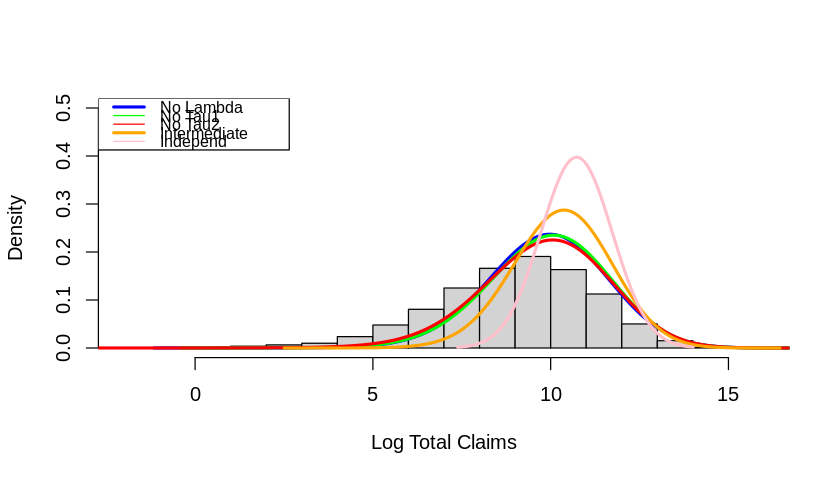

In [ ]:

#Density Comparison
hist(log(SumDatBase1[[2]]), main="", ylim=c(0,.5),xlab="Log Total Claims", freq=FALSE, col="lightgray", breaks = 25)
lines(density(log(SumDatBase2[[2]]), bw=1), col="blue",lwd=2.5)
lines(density(log(SumDatBase3[[2]]), bw=1), col="green",lwd=2.5)
lines(density(log(SumDatBase4[[2]]), bw=1), col="red",lwd=2.5)
lines(density(log(SumDatBase5[[2]]), bw=1), col="orange",lwd=2.5)
lines(density(log(SumDatBase6[[2]]), bw=1), col="pink",lwd=2.5)
legend("topleft", c("No Lambda", "No Tau1", "No Tau2",
                    "Intermediate", "Independ"), lty=c(1,1,1), lwd=c(2.5,1,1),
       col=c("blue", "green", "red", "orange", "pink"), cex=0.8)

Think about how you would interpret the importance of these findings to a manager. (Hint: remember that we usually think about a predictive distribution as the key input to a *loss reserve*.)

# Demonstration 2. Bühlmann’s Top-Down Pricing Approach with NFIP Data



Now consider two cases, the most likely under a model that permits dependence and a model that (although very good) assumes independent risks.

In [ ]:

GetData.fct(file = "testDataSamp_08June2026.RData")
GetData.fct(file = "testDataSampInd_08June2026.RData")
#ls.str() # List objects with details

The `RetClaims.fct` function is a bit more general than we need right now but will be handy later when we introduce retention functions. In this application, I set the coefficients essentially to infinity (1e12) meaning that the owner is retaining all risks, no transfer yet.

In [ ]:
#  Retained Claims
RetClaims.fct <- function(coeff, optData, ClusterVar="Cluster" , ExLoss) {
  theta <- coeff[-1]
  ClmMat <- as.matrix( optData[, -c(1:3)] )
  cluster <- as.numeric(optData[[ClusterVar]])
  Cluster_ID     <- sort(unique( cluster))
  cluster_index <- match( cluster, Cluster_ID)
  if (ExLoss) {
    limit <- optData$Coverage * theta[cluster_index]
    return(colSums(pmin(ClmMat, limit)))
  } else {
    theta_long <- theta[cluster_index]
    return(as.numeric(crossprod(theta_long, ClmMat)))
  }
}  # end RetClaims.fct function

coeffBase <- c(0,rep(1e12, 5))

alpha           <- 0.8  # Confidence level
ClusterVar      <- "Cluster"
ExLoss          <- TRUE

BuhlmannPrice <- function(coeff, optData){
 RetClm <- RetClaims.fct(coeff, optData, ClusterVar, ExLoss)
 ExpCost        <- mean(RetClm)
 VarCost        <- quantile(RetClm, probs = 0.98)
 CapitalRequire <- VarCost - ExpCost
 CostCapital    <- 100 * (0.05) * CapitalRequire / ExpCost
 return(c(ExpCost, VarCost, CapitalRequire, CostCapital))
 }
Row1 <- BuhlmannPrice(coeff=coeffBase, optData=testData)
Row3 <- BuhlmannPrice(coeff=coeffBase, optData=testDataInd)
TableOut <- rbind(Row1, Row3)

rownames(TableOut) <- c("Test Data Dependent", "Test Data Independent")
colnames(TableOut) <- c("Expected Cost", "VaR Cost", "Capital Required", "Cost of Capital")
print('Buhlmanns Top-Down Pricing Strategy')
TableOut

[1] "Buhlmanns Top-Down Pricing Strategy"


,Expected Cost,VaR Cost,Capital Required,Cost of Capital
Test Data Dependent,46108.69,387690.97,341582.274,37.0409854
Test Data Independent,45853.23,54349.99,8496.764,0.9265175


For example, consider the top row of the table  that assumes spatially dependent claims retention levels assuming spatially dependence. Here, the expected retained claims are 46109 (thousands). The value at risk at the 98% level turns out to be 387691. If we utilize fair pricing, then capital required is 387691 - 46109 = 341582. If the rate of return on capital is 5%, then the cost of capital is 17079, or 37% of the fair cost.

# Excess of Loss by Cluster Retention Plans

For risk retention plans, let us think about partitioning the 26174 policyholders into $K=5$ clusters.

The cluster variable is
$$
\text{Cluster} =
\left\{
\begin{array}{ll}
1 & \text{Single Family, Non elevated, Built after 1989 }\\
2 & \text{Single Family, Non elevated, Built in or before 1989 }\\
3 & \text{Single Family, Elevated }\\
4 & \text{Multi-unit Residential}\\
5 & \text{Non-residential or Other}\\
\end{array}
\right.
$$

## Summary Statistics by Cluster

To get a feel for the data, here are some summary statistics by cluster.


In [ ]:
#  Coverage by Cluster
#library(dplyr)
TableCoverage <- testData %>%
  group_by(Cluster) %>%
  summarise(
    n = n(),
    mean_ = mean(CoverageBC, na.rm = TRUE),
    sd_ = sd(CoverageBC, na.rm = TRUE),
    min_ = min(CoverageBC, na.rm = TRUE),
    max_ = max(CoverageBC, na.rm = TRUE)
  )
TableCoverage
print('Summaries of Coverage by Cluster (in thousands)')


Cluster,n,mean_,sd_,min_,max_
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,10457,329.1336,53.97473,2,350
2,10515,304.6351,68.13947,6,350
3,2036,317.7605,56.00795,5,600
4,603,350.0987,136.64002,20,600
5,2563,329.2025,278.38275,4,1000


[1] "Summaries of Coverage by Cluster (in thousands)"



This table shows that cluster 4 has the fewest number of policyholders.


In [ ]:
testData1 = testData
testData1$AvgClaims <-  rowMeans(testData[,-c(1,2,3)])
TableClaims <- testData1 %>%
  group_by(Cluster) %>%
  summarise(
    n = n(),
    mean_ = mean(AvgClaims, na.rm = TRUE),
    sd_ = sd(AvgClaims, na.rm = TRUE),
    min_ = min(AvgClaims, na.rm = TRUE),
    max_ = max(AvgClaims, na.rm = TRUE)
  )
rm(testData1)
print('Summaries of Average Claims by Cluster (in thousands). Averages are over 10000 simulations.')
TableClaims

[1] "Summaries of Average Claims by Cluster (in thousands). Averages are over 10000 simulations."


Cluster,n,mean_,sd_,min_,max_
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,10457,0.8585975,0.801755,0.0014838363,11.71558
2,10515,2.3294619,2.555313,0.0143815408,46.77499
3,2036,2.5339789,2.571264,0.0084890204,27.06327
4,603,2.6919769,3.416931,0.0006343323,46.30638
5,2563,2.2838873,4.731651,0.0000000000,75.37638


## Excess of Loss Plans

To recap, the simulated loss distributions are based on 1000 simulated replicates  for **each** of 26174 policyholders.

As before, now think about $K$ clusters where there are $n_k$ entities in the $k$th cluster. Associated with each cluster is an upper
limit retention level. For the $j$th entity in the $k$th cluster, let
$C_{kj}$ denote the coverage. For this entity. the  upper limit
is proportional to the coverage, so $u_{jk} = \theta_k \times C_{kj}$. To
allow some flexibility, we allow the proportions to vary by cluster.
Thus, the risk owner retains

$$
g({\bf X}; \boldsymbol \theta) = g({\bf X};\theta_1, \ldots, \theta_K) = \sum_{k=1}^K \sum_{j \in N_k} \min(\theta_k C_{kj}, X_{kj}) .
$$

With this construction, the $\theta_k$ non-negative. One might also impose an upper bound $\theta_k \le 1$ to prevent over-insurance and thus moral hazard.

### Code for Optimal Risk Transfer

The code includes a smoothed version of the expected shortfall risk measure. We consider here the following constrained optimization problem

$$
\boxed{
\begin{array}{cccc}
{\small \text{minimize}}_{{\boldsymbol \theta}}& RM({\boldsymbol \theta}) & {\small \textit{uncertainty} } \\
 {\small \text{subject to}}  &
RTC({\boldsymbol \theta})  \le RTC_{max}& {\small\textit{budget }}\\
\end{array}
}
$$

#### Preliminary Functions

In [ ]:
#  Functions for Constrained Optimization

#  Retained Claims
RetClaims.fct <- function(coeff, optData, ClusterVar="Cluster" , ExLoss) {
  theta   <- coeff[-1]
  ClmMat  <- as.matrix( optData[, -c(1:3)] )
  cluster <- as.numeric(optData[[ClusterVar]])
  Cluster_ID    <- sort(unique( cluster))
  cluster_index <- match( cluster, Cluster_ID)
  if (ExLoss) {
    limit <- optData$Coverage * theta[cluster_index]
    return(colSums(pmin(ClmMat, limit)))
  } else {
    theta_long <- theta[cluster_index]
    return(as.numeric(crossprod(theta_long, ClmMat)))
  }
}  # end RetClaims.fct function

#  ESKernmin.fct evaluates the ES objective function using kernel smoothing
#bw = 1   # Bandwidth

ESKernmin.fct <- function(coeff, optData, ClusterVar, ExLoss ) {
 # coeff <- fT(coeff)
  z0 <- coeff[1]
  RetClaims <- RetClaims.fct(coeff, optData, ClusterVar, ExLoss )
  d <- RetClaims - z0
  u <- d / bw
  smooth_excess <- d * pnorm(u) + bw * dnorm(u)
  z0 + mean(smooth_excess) / (1 - alpha)
}   # end ESKernmin.fct function

# generated by ChatGPT !!!
grad_ESKernmin.fct <- function(coeff, optData, ClusterVar, ExLoss) {

  z0 <- coeff[1]
  ClmMat <- as.matrix( optData[, -c(1:3)] )
  RetClaims <- RetClaims.fct(coeff, optData, ClusterVar, ExLoss)
  d <- RetClaims - z0
  u <- d / bw
  w <- pnorm(u)
  n <- length(RetClaims)
  grad <- numeric(length(coeff))
  # derivative with respect to z0
  grad[1] <- 1 - mean(w) / (1 - alpha)
  # derivatives with respect to theta_j
  cluster <- as.numeric(optData[[ClusterVar]])
  Cluster_ID     <- sort(unique( cluster))
  cluster_index <- match( cluster, Cluster_ID)
  if (!ExLoss) {  #  Quota Share
    for (j in seq_along(Cluster_ID)) {
      rows_j <- which(cluster_index == j)
      dR_dtheta_j <- colSums(ClmMat[rows_j, , drop = FALSE])
      grad[j + 1] <- mean(w * dR_dtheta_j) / (1 - alpha)
    }
  } else {   # Excess of Loss
    for (j in seq_along(Cluster_ID)) {
      rows_j <- which(cluster_index == j)
      theta_j <- coeff[j + 1]
      limit_j <- optData$Coverage[rows_j] * theta_j
      # derivative of pmin(X, Coverage * theta)
      # is Coverage when X > limit, 0 when X < limit
      # undefined at equality; use 0 or Coverage there
      active <- sweep(ClmMat[rows_j, , drop = FALSE], 1, limit_j, ">")
      dR_dtheta_j <- colSums(active * optData$Coverage[rows_j])
      grad[j + 1] <- mean(w * dR_dtheta_j) / (1 - alpha)
    }
  }   #  end Excess of Loss option
  return(grad)
}  #  end grad_ESKernmin.fct function

#  Summary Retained Claims
ESSummary.fct <- function(coeff, optData, ClusterVar, ExLoss){
  RetClaims <- RetClaims.fct(coeff, optData, ClusterVar, ExLoss )
  ClmMat    <- as.matrix( optData[, -c(1:3)] )
  TotalClaims  <- colSums(ClmMat)
  CeededClaims <- TotalClaims - RetClaims
  RTC.R     <- mean( CeededClaims )
  stddev    <- sd(RetClaims)
  VaR       <- as.numeric(quantile(RetClaims, prob = alpha, na.rm = TRUE))
  ES        <- as.numeric(VaR   +
                          mean(pmax(RetClaims - VaR,   0)) / (1-alpha) )
  return( c(RTC.R, VaR, ES, stddev) )
  } # end ESSummary.fct function

#  Constraint Functions
PmatCluster.fct <- function(coeff, optData, ClusterVar, ExLoss, RTCmax){
  theta.vec   <- coeff[-1]
  numCluster  <- length( table(optData$Cluster) )
  h <- NA
  h[1] <- RTCmax - ESSummary.fct(coeff, optData, ClusterVar, ExLoss )[1]
  for (j in 1:numCluster){ h[j+1] <- 1e6*theta.vec[j] }
  if (! ExLoss){  # Place an upper bound of 1 for Quota Share
  for (j in 1:numCluster){ h[numCluster + j+1] <- 1e6*(100 - theta.vec[j]) }
  }
  return(h)
} # end PmatCluster.fct function


### Single Run of the Problem

The first three columns of the file "TestData" are "Cluster", "CoverageBC", and "tractID". After this there are 10,000 columns of simulated claims. We first need to reformat the data, taking only a sample of 'NumTract' (out of 300) census tracts and 'NumSim' columns of simulated claims.

I also experimented with different scales (not used now).





In [ ]:
#  Change the Number of Tracts and Simulation
ChgDim.fct <- function(dataSet, numTract, NumSim){
  set.seed(2)
  nTract        <- table(dataSet$tractID)
  # length(nTract)
  sample.Tracts <- sample(nTract, size = numTract, replace = FALSE)
  tractNames    <- names(sample.Tracts)
  samp.dataSet  <- subset(dataSet, tractID %in% tractNames)
  claim_names   <- paste0("RandClm", 1:NumSim)
  ClmMatBase    <- as.matrix(samp.dataSet[, claim_names])   # rows = policies, cols = simulations
  ClmMatNew     <- as.matrix(samp.dataSet[, claim_names])
  optDataNew    <- cbind(samp.dataSet[,c("CoverageBC", "Cluster", "tractID")], ClmMatNew)
  return(optDataNew)
}  # end ChgDim.fct

#fT <- function(y){ exp( y) }  # Now move to log scale
#fT <- function(y){ c( y[1], exp( y[-1]) ) }  # Now move to log scale
#fTInv <- function(y){ c( y[1], log( y[-1]) ) }  # Now move back from log scale
fT <- function(y){y }  # Now move to the original scale
fTInv <- function(y){y }

In [ ]:

TimeCheckB      <- Sys.time()
#library(alabama)
#  all 300 census tracks takes about 25 minutes so let us use a smaller sample
#optData <- ChgDim.fct(dataSet = testData, numTract=300, NumSim=1000)
optData <- ChgDim.fct(dataSet = testData, numTract=30, NumSim=1000)
alpha           <- 0.8  # Confidence level
bw              <- 1    # Bandwidth
NumSim          <- 1000

ClusterVar    <-  "Cluster"   # "tractID"  #
numCluster    <- length(unique(optData[[ClusterVar]]))
numCoeff      <- numCluster + 1
ExLoss        <- TRUE  #  Choose the Retention plan ...

starterXL.coeff <- fTInv( c(5e3, rep(.1, numCluster)) )

RTCmax   <- 0.5 * ESSummary.fct(rep(0,numCoeff), optData, ClusterVar, ExLoss)[1]

f0XL.fct   <- function(coeff){ coeff <- fT(coeff)
                ESKernmin.fct(coeff, optData, ClusterVar, ExLoss)  }
f0.grad    <- function(coeff){  coeff <- fT(coeff)
                grad_ESKernmin.fct(coeff, optData, ClusterVar, ExLoss) }
PmatXLTran.fct <- function(coeff, optData, ClusterVar, ExLoss, RTCmax){h <- NA
        h[1] <- RTCmax - ESSummary.fct(coeff, optData, ClusterVar, ExLoss )[1]
        return(h)
    }
PmatXL.fct <- function(coeff){ coeff <- fT(coeff)
  PmatXLTran.fct(coeff, optData, ClusterVar, ExLoss, RTCmax) }

#  Optimization using 'alabama' package
fXL.opt <- alabama::auglag( par = starterXL.coeff,
                            fn  = f0XL.fct,  hin = PmatXL.fct,
                            gr  = f0.grad,       # gradient objective function
           control.outer=list(method="nlminb",trace=FALSE) )

SumStatMat <- ESSummary.fct(fT(fXL.opt$par), optData, ClusterVar, ExLoss)
parmMat    <- fT(fXL.opt$par)[-1]
cat("RTCmax",RTCmax, "\n")
cat("Summary Results",SumStatMat, "\n")
cat("Parameter Results",parmMat, "\n")

Sys.time() - TimeCheckB

RTCmax 2939.53 
Summary Results 2939.53 3789.429 13456.84 8735.044 
Parameter Results -6.075034e-05 0.8418646 0.7210021 -0.01831803 -0.001641877 


Time difference of 2.712406 mins

### Frontier

Now repeat for different levels of $RTC_{max}$. Here are the results. The code is in the online supplement.

In [ ]:
#save(SumStatMat, parmMat, file="../RDataFiles/BaseNTract_300_NSim_1000_13June2026Cluster.RData")
GetData.fct(file = "BaseNTract_300_NSim_1000_13June2026Cluster.RData")

rownames(SumStatMat) <- c("0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9")
colnames(SumStatMat) <- c("RTC", "VaR", "ES", "StdDev")
SumStatMat
print('Summary Statistics (in thousands) by RTCmax Proportion')

,RTC,VaR,ES,StdDev
0.1,4440.847,50445.181,156854.23,105518.293
0.2,8881.694,45699.800,138245.73,91048.337
0.3,13322.540,40358.399,120339.15,78822.618
0.4,17763.387,34518.214,102824.70,66734.803
0.5,22204.234,28643.935,85728.17,56203.801
0.6,26645.081,24727.795,66654.42,38723.956
0.7,31085.928,18497.113,49938.38,28782.527
0.8,35526.775,12536.738,32996.30,18805.971
0.9,39967.621,6490.198,15951.66,8672.812


[1] "Summary Statistics (in thousands) by RTCmax Proportion"


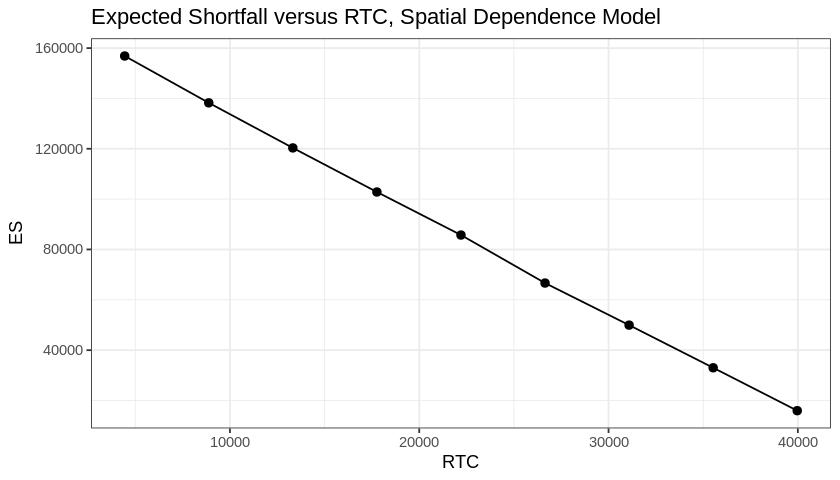

In [ ]:
# For plotting, convert matrix to data frame
df <- as.data.frame(SumStatMat)

# Basic scatter/line plot
#library(ggplot2)
ggplot(df, aes(x = RTC, y = ES)) +
  geom_point(size = 2) +
  geom_line() +
  labs(
    title = "Expected Shortfall versus RTC, Spatial Dependence Model",
    x = "RTC", y = "ES" ) +   theme_bw()

In the online supplement, you will find similar demonstrations for the independent predictive distribution and for the quota share retention plane.

The implications of these demonstrations are important but the code is very similar and so not included here.

# Demonstration 3. Retention Proportions - All 5,508 Census Tracts

Now, we are switching to the quota share retention plan. Because this plan is linear in the retention coefficients, when minimizing expected shortfall, this turns out to be a linear programming problem! So, we can use constrained optimization routines that rely on the convexity. These are very fast and so we can handle much larger data sets really easily.

In [ ]:
# Code for installing CVXR - takes about 5-7 minutes!!
system('sudo apt-get update && sudo apt-get install -y libgmp-dev libmpfr-dev')
install.packages("remotes",
  repos = "https://cloud.r-project.org" )

remotes::install_version(package = "CVXR",
  version = "1.0-15",repos = "https://cloud.r-project.org",
  upgrade = "never")
library(CVXR)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘CVXR’


The following object is masked from ‘package:stats’:

    power




In [ ]:
This big data set consists of 1000 simulated values for each of 547978 risks (homeowners). As I recall, the optimization takes only about 5 minutes...

Total Cost 862084.7 
Summary Results 431042.4 655901.1 1410586 703159.1 


Time difference of 4.223332 mins

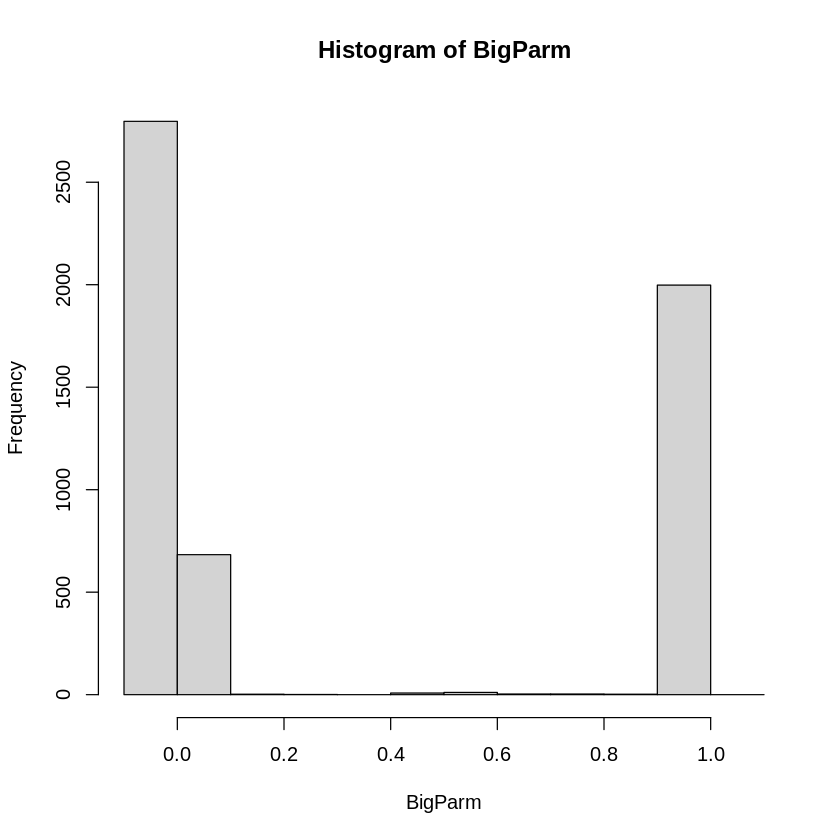

In [ ]:
#  Try with CVXR
#   547978 obs. of  1003 variables
#save(nsim, numPol, testData, file = "testDataBig_19June2026.RData")
GetData.fct(file = "testDataBig_19June2026.RData")

optData <- testData
ClusterVar    <- "tractID"    #   Cluster"   #
numCluster    <- length(unique(optData[[ClusterVar]]))

ClmMat        <- as.matrix( optData[, -c(1:3)] )
cluster       <- optData[[ClusterVar]]
ClusterClaims <- t(rowsum(ClmMat, cluster))
ClusterNames  <- colnames(ClusterClaims)
Cluster.mu    <- colMeans(ClusterClaims)
Cluster.Sigma <- var(ClusterClaims)

TimeCheckB      <- Sys.time()
#library(CVXR)
TotCost <- sum(Cluster.mu)
RTCmax  <- 0.5 * TotCost
alpha   <- 0.80

pos_part <- function(z) { 0.5 * ( z + abs(z) ) }

### Minimize Expected Shortfall
coeff         <- Variable(numCluster + 1)
VaR.z0        <- coeff[1]
theta.vec     <- coeff[-1]
Claims.retained <- ClusterClaims %*% theta.vec
RTC           <- TotCost - t(theta.vec) %*% Cluster.mu
constraints   <- list(RTC <= RTCmax,
                      coeff >= 0, theta.vec <= 1)
objES         <- VaR.z0 +
                 mean( pos_part(Claims.retained  - VaR.z0) ) / (1-alpha)
probES        <- Problem(Minimize(objES), constraints)
CVXR.ESresult <- solve(probES, solver = "ECOS")

coeffES.opt   <- as.vector(CVXR.ESresult$getValue(coeff))
parmMat        <- coeffES.opt
names(parmMat) <- c("VaR", ClusterNames)

# Summarize Results
SumCVXR.fct <- function(theta){
  RTC      <- TotCost - t(theta) %*% Cluster.mu
  Variance <- t(theta) %*% Cluster.Sigma %*% theta
  Claims.retained <- ClusterClaims %*% theta
  VaR      <- quantile(Claims.retained, prob = alpha)
  ES       <- VaR + mean(pmax(Claims.retained - VaR, 0))/(1-alpha)
  output   <- c(RTC, VaR, ES, sqrt(Variance) )
  return(output)
}
SumStatMat <- SumCVXR.fct(coeffES.opt[-1])

cat("Total Cost", SumCVXR.fct(rep(0,numCluster))[1], "\n")
cat("Summary Results",SumStatMat, "\n")
#cat("Parameter Results",parmMat, "\n")

BigParm <- coeffES.opt[-1]
hist(BigParm )
Sys.time() - TimeCheckB
#save(BigParm, file = "../RDataFiles/BigParm_20Aug2026.RData")


In [ ]:
From the plot, we learn that parameters are mostly 0's and 1's. The algorithm recommends that policyholders are in or out of the of the optimal pool.

In [ ]:
# These libraries also take about 10 minutes to install....
install.packages(c("tigris", "sf"))
library(tigris)
library(sf)

GetData.fct(file = "BigParm_20Aug2026.RData")

tractID_keep  <- ClusterNames

download.file("https://users.ssc.wisc.edu/~ewfrees/SpatialData/SampleData.rds",
              destfile = "SampleData.rds")
dat <- readRDS("SampleData.rds")  # 3,296,213 X 56
setDT(dat) # Convert to data.table

keepvar <- c("GEOID", "INTPTLAT", "INTPTLON", "tractID")
dat_sub <- dat[, ..keepvar ]

dat_sub1 <- dat_sub[dat_sub$tractID %in% tractID_keep]
dat_sub2 <- unique(dat_sub1, by = "tractID")

# need to transform lon and lat to meters
#library(sf)
sf_pts <- st_as_sf(dat_sub2,
                   coords = c("INTPTLON","INTPTLAT"),
                   crs = 4326)
sf_proj <- st_transform(sf_pts, 26917)  # UTM 17N for florida
coords <- st_coordinates(sf_proj)

# Universal Transverse Mercator
dat_sub2$utm_easting  <- coords[,1]
dat_sub2$utm_northing <- coords[,2]
ParmMat_Geo <- cbind(dat_sub2, BigParm)

str(ParmMat_Geo )

#save(ParmMat_Geo, file="BigQuotaParmGeoCode_16June2026Tract.RData")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

To enable caching of data, set `options(tigris_use_cache = TRUE)`
in your R script or .Rprofile.

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3.1; sf_use_s2() is TRUE



Classes ‘data.table’ and 'data.frame':	5508 obs. of  7 variables:
 $ GEOID       : chr  "12001000200" "12001000301" "12001000302" "12001000400" ...
 $ INTPTLAT    : num  29.7 29.7 29.7 29.7 29.7 ...
 $ INTPTLON    : num  -82.3 -82.3 -82.3 -82.3 -82.3 ...
 $ tractID     : chr  "12001000200" "12001000301" "12001000302" "12001000400" ...
 $ utm_easting : num  370944 371157 371308 373426 372545 ...
 $ utm_northing: num  3280870 3282739 3284537 3283985 3281487 ...
 $ BigParm     : num  4.21e-08 6.61e-10 1.00 1.00 1.19e-09 ...
 - attr(*, ".internal.selfref")=<pointer: 0x57a4eef56010> 


To enable caching of data, set `options(tigris_use_cache = TRUE)`
in your R script or .Rprofile.



  |======================================================================| 100%


Retrieving data for the year 2024



  |======================================================================| 100%


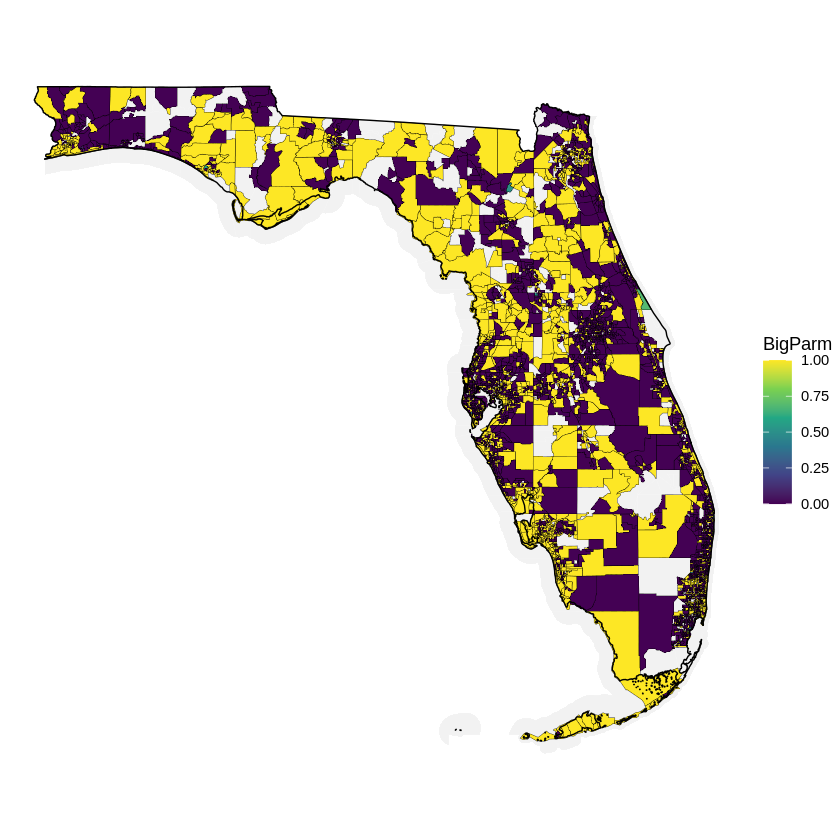

In [ ]:
library(dplyr)
library(ggplot2)
GetData.fct( file = "BigQuotaParmGeoCode_16June2026Tract.RData")
library(sf)
library(tigris)

fl_tracts <- tracts(state = "FL", year = 2020, class = "sf")

fl_plot <- fl_tracts %>%
  inner_join(ParmMat_Geo[, c("GEOID", "BigParm")], by = "GEOID")

fl_state <- states(cb = TRUE, class = "sf") %>%
  filter(STUSPS == "FL")

ggplot() +
  geom_sf(data = fl_tracts,
          fill = "gray95",
          color = "white",
          linewidth = 0.02) +
  geom_sf(data = fl_plot,
          aes(fill = BigParm),
          color = "black",
          linewidth = 0.1) +
  geom_sf(data = fl_state,
          fill = NA,
          color = "black",
          linewidth = 0.4) +
  scale_fill_viridis_c() +
  theme_void()

#ggsave("Florida_Big.png", width = 7, height = 5, dpi = 300)

The figure shows, quite naturally, clusters of policyholders that are in or out of the optimal pool. This is exactly what we would expect under a spatially dependent model. (Recall that under a model of independence, we would expect to see much less clustering...)

# Demonstration 4. Risk Exchange Predictive Distributons

Take two samples, the "dat_south" has 1000 policyholders that are farthest to the south, the "dat_north" has 5000 policyholders that are farthest to the north.


See the code at

https://users.ssc.wisc.edu/~ewfrees/SpatialData/FloodCode2026.html